# EnergyPhysicsBench — 1D Heat Diffusion
## Analytical ground truth, finite differences, and a machine-learning surrogate

This notebook builds a complete first benchmark for learned physics modelling.

We will:

1. define a transient one-dimensional heat-diffusion problem;
2. obtain an analytical solution for a family of initial conditions;
3. implement the explicit Forward-Time Central-Space finite-difference method;
4. validate the numerical solver against the analytical ground truth;
5. perform a grid-convergence and physical-behaviour check;
6. train a neural-network surrogate to predict the temperature field;
7. compare analytical, FDM, and ML results in accuracy, speed, physical consistency, and out-of-distribution behaviour.

The objective is not merely to make a neural network fit a curve. The objective is to understand **what each modelling approach knows, where its accuracy comes from, and where it fails**.

## Environment

Required packages:

```powershell
pip install numpy matplotlib scikit-learn
```

The first two are used for numerical work and visualisation. `scikit-learn` provides the baseline multilayer perceptron used in the ML section.

In [1]:
# Uncomment and run this cell only if a package is missing.
# %pip install numpy matplotlib scikit-learn

In [2]:
from __future__ import annotations

import platform
import sys
import time
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import sklearn
from sklearn.neural_network import MLPRegressor
from sklearn.preprocessing import StandardScaler

SEED = 42
rng = np.random.default_rng(SEED)

print(f"Python:       {sys.version.split()[0]}")
print(f"NumPy:        {np.__version__}")
print(f"Matplotlib:   {plt.matplotlib.__version__}")
print(f"scikit-learn: {sklearn.__version__}")
print(f"Platform:     {platform.platform()}")

Python:       3.13.5
NumPy:        2.3.5
Matplotlib:   3.10.8
scikit-learn: 1.8.0
Platform:     Linux-6.18.35-x86_64-with-glibc2.41


# 1. Physical problem

Consider a homogeneous rod of length $L$. Its temperature is $T(x,t)$, and both ends are held at a fixed baseline temperature $T_b$.

It is convenient to work with the **excess temperature**

$$
u(x,t) = T(x,t)-T_b.
$$

The baseline then becomes zero, and the governing problem is

$$
\frac{\partial u}{\partial t}
=
\alpha\frac{\partial^2u}{\partial x^2},
\qquad 0<x<L,
$$

with fixed-temperature boundary conditions

$$
u(0,t)=u(L,t)=0.
$$

Here

$$
\alpha=\frac{k}{\rho c_p}
$$

is the thermal diffusivity, measured in $\mathrm{m^2/s}$.

The benchmark uses:

- $L=1\,\mathrm m$;
- $T_b=20^\circ\mathrm C$;
- $\alpha=10^{-4}\,\mathrm{m^2/s}$;
- a one-dimensional grid with 51 points unless stated otherwise.

In [3]:
# Physical parameters
L = 1.0                 # rod length [m]
alpha = 1.0e-4          # thermal diffusivity [m^2/s]
T_base = 20.0           # fixed boundary/reference temperature [deg C]

# Default numerical grid
Nx = 51
x = np.linspace(0.0, L, Nx)
dx = x[1] - x[0]

# Target FTCS stability number
r_target = 0.4

dt_nominal = r_target * dx**2 / alpha

print(f"L           = {L:.3f} m")
print(f"alpha       = {alpha:.2e} m^2/s")
print(f"Nx          = {Nx}")
print(f"dx          = {dx:.4f} m")
print(f"nominal dt  = {dt_nominal:.4f} s")
print(f"target r    = {r_target:.3f}")

L           = 1.000 m
alpha       = 1.00e-04 m^2/s
Nx          = 51
dx          = 0.0200 m
nominal dt  = 1.6000 s
target r    = 0.400


# 2. Analytical ground truth

For the fixed-end problem, sine functions are eigenfunctions of the spatial diffusion operator. If the initial excess temperature is

$$
u(x,0)=A\sin\left(\frac{m\pi x}{L}\right),
$$

then the exact solution is

$$
u(x,t)=A\sin\left(\frac{m\pi x}{L}\right)
\exp\left[-\alpha\left(\frac{m\pi}{L}\right)^2t\right].
$$

The spatial shape remains a sine wave. Diffusion only reduces its amplitude exponentially.

For the first mode, the characteristic decay time is

$$
\tau_1=\frac{L^2}{\alpha\pi^2}.
$$

At $t=\tau_1$, the initial amplitude has fallen to $e^{-1}\approx36.8\%$ of its original value.

In [4]:
def exact_single_mode(
    x: np.ndarray,
    t: float,
    *,
    amplitude: float,
    mode: int,
    length: float,
    diffusivity: float,
) -> np.ndarray:
    """Exact excess-temperature field for one sine eigenmode."""
    wave_number = mode * np.pi / length
    return (
        amplitude
        * np.sin(wave_number * x)
        * np.exp(-diffusivity * wave_number**2 * t)
    )


amplitude = 80.0
mode = 1
characteristic_time = L**2 / (alpha * np.pi**2)

print(f"First-mode characteristic time: {characteristic_time:.2f} s")

First-mode characteristic time: 1013.21 s


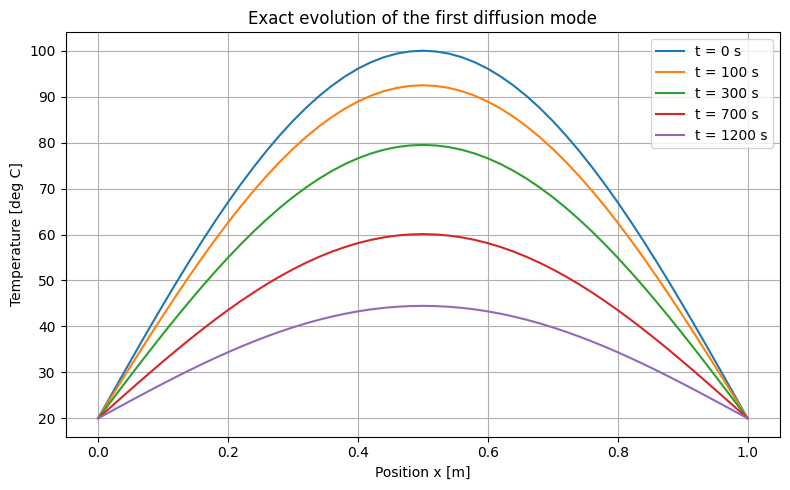

In [5]:
exact_plot_times = [0.0, 100.0, 300.0, 700.0, 1200.0]

plt.figure(figsize=(8, 5))
for t_value in exact_plot_times:
    u_exact = exact_single_mode(
        x,
        t_value,
        amplitude=amplitude,
        mode=mode,
        length=L,
        diffusivity=alpha,
    )
    plt.plot(x, T_base + u_exact, label=f"t = {t_value:.0f} s")

plt.xlabel("Position x [m]")
plt.ylabel("Temperature [deg C]")
plt.title("Exact evolution of the first diffusion mode")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 3. Finite-difference model

We discretise space using points $x_i=i\Delta x$ and time using levels $t^n=n\Delta t$.

A forward difference approximates the time derivative:

$$
\frac{\partial u}{\partial t}
\approx
\frac{u_i^{n+1}-u_i^n}{\Delta t}.
$$

A centred difference approximates the second spatial derivative:

$$
\frac{\partial^2u}{\partial x^2}
\approx
\frac{u_{i+1}^n-2u_i^n+u_{i-1}^n}{\Delta x^2}.
$$

Substitution gives the explicit FTCS update

$$
u_i^{n+1}
=
u_i^n
+r\left(u_{i+1}^n-2u_i^n+u_{i-1}^n\right),
$$

where

$$
r=\frac{\alpha\Delta t}{\Delta x^2}.
$$

In one spatial dimension, FTCS is stable only when

$$
0\le r\le\frac12.
$$

The solver below selects a number of time steps that reaches the requested final time exactly while respecting a target value of $r$.

In [6]:
@dataclass(frozen=True)
class FTCSDiagnostics:
    n_steps: int
    dt: float
    r: float


def solve_ftcs(
    u_initial: np.ndarray,
    x_grid: np.ndarray,
    diffusivity: float,
    final_time: float,
    *,
    target_r: float = 0.4,
) -> tuple[np.ndarray, FTCSDiagnostics]:
    """
    Solve the 1D heat equation with fixed-zero excess-temperature boundaries.

    Parameters
    ----------
    u_initial:
        Initial excess-temperature values on x_grid.
    x_grid:
        Uniform spatial grid.
    diffusivity:
        Thermal diffusivity alpha.
    final_time:
        Requested output time.
    target_r:
        Desired alpha*dt/dx^2. Must not exceed 0.5.
    """
    u_initial = np.asarray(u_initial, dtype=float)
    x_grid = np.asarray(x_grid, dtype=float)

    if u_initial.shape != x_grid.shape:
        raise ValueError("u_initial and x_grid must have the same shape.")
    if final_time < 0.0:
        raise ValueError("final_time must be non-negative.")
    if not (0.0 < target_r <= 0.5):
        raise ValueError("target_r must satisfy 0 < target_r <= 0.5.")
    if len(x_grid) < 3:
        raise ValueError("At least three grid points are required.")

    grid_spacings = np.diff(x_grid)
    dx_local = grid_spacings[0]
    if not np.allclose(grid_spacings, dx_local):
        raise ValueError("FTCS implementation requires a uniform grid.")

    if final_time == 0.0:
        return u_initial.copy(), FTCSDiagnostics(n_steps=0, dt=0.0, r=0.0)

    largest_dt = target_r * dx_local**2 / diffusivity
    n_steps = int(np.ceil(final_time / largest_dt))
    dt = final_time / n_steps
    r = diffusivity * dt / dx_local**2

    u = u_initial.copy()
    u[0] = 0.0
    u[-1] = 0.0

    for _ in range(n_steps):
        u_new = u.copy()
        u_new[1:-1] = u[1:-1] + r * (
            u[2:] - 2.0 * u[1:-1] + u[:-2]
        )
        u_new[0] = 0.0
        u_new[-1] = 0.0
        u = u_new

    return u, FTCSDiagnostics(n_steps=n_steps, dt=dt, r=r)


def error_metrics(reference: np.ndarray, prediction: np.ndarray) -> dict[str, float]:
    """Return common pointwise error metrics."""
    error = np.asarray(prediction) - np.asarray(reference)
    return {
        "MAE": float(np.mean(np.abs(error))),
        "RMSE": float(np.sqrt(np.mean(error**2))),
        "MaxAbs": float(np.max(np.abs(error))),
    }

## 3.1 FDM versus the analytical solution

We initialise the FDM solver with the exact first sine mode and compare both methods at $t=700\,\mathrm s$.

Because the analytical solution is exact for this problem, the difference measures the numerical discretisation error of the FTCS model.

In [7]:
comparison_time = 700.0

u_initial = exact_single_mode(
    x,
    0.0,
    amplitude=amplitude,
    mode=mode,
    length=L,
    diffusivity=alpha,
)

u_analytical = exact_single_mode(
    x,
    comparison_time,
    amplitude=amplitude,
    mode=mode,
    length=L,
    diffusivity=alpha,
)

u_fdm, fdm_diagnostics = solve_ftcs(
    u_initial,
    x,
    alpha,
    comparison_time,
    target_r=r_target,
)

fdm_metrics = error_metrics(u_analytical, u_fdm)

print(f"Number of FTCS steps: {fdm_diagnostics.n_steps}")
print(f"Actual dt:            {fdm_diagnostics.dt:.6f} s")
print(f"Actual r:             {fdm_diagnostics.r:.6f}")
print()
for name, value in fdm_metrics.items():
    print(f"{name:>6}: {value:.8f} deg C")

Number of FTCS steps: 438
Actual dt:            1.598174 s
Actual r:             0.399543

   MAE: 0.00794884 deg C
  RMSE: 0.00891973 deg C
MaxAbs: 0.01273992 deg C


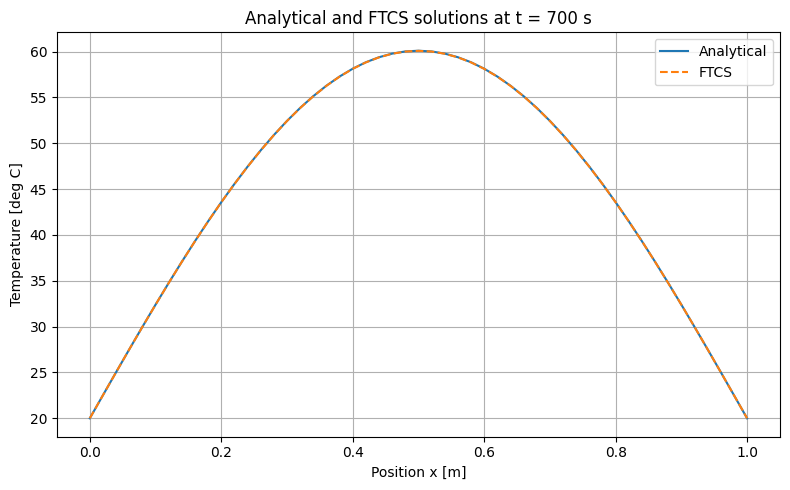

In [8]:
plt.figure(figsize=(8, 5))
plt.plot(x, T_base + u_analytical, label="Analytical")
plt.plot(x, T_base + u_fdm, "--", label="FTCS")
plt.xlabel("Position x [m]")
plt.ylabel("Temperature [deg C]")
plt.title(f"Analytical and FTCS solutions at t = {comparison_time:.0f} s")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

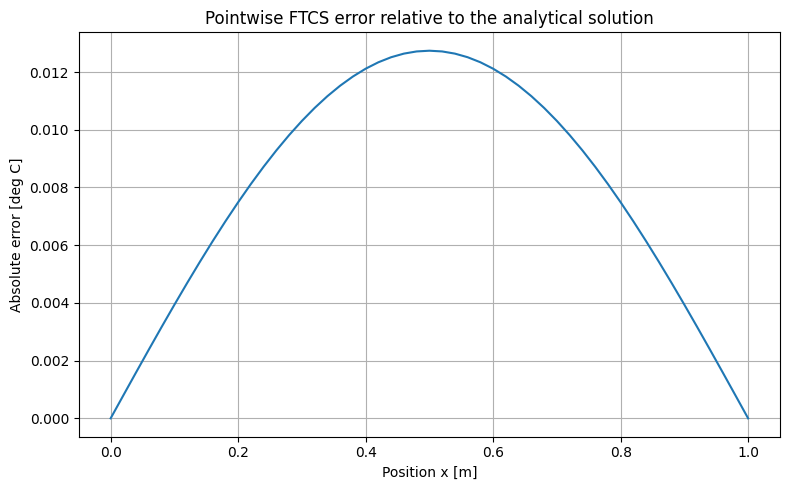

In [9]:
plt.figure(figsize=(8, 5))
plt.plot(x, np.abs(u_fdm - u_analytical))
plt.xlabel("Position x [m]")
plt.ylabel("Absolute error [deg C]")
plt.title("Pointwise FTCS error relative to the analytical solution")
plt.grid(True)
plt.tight_layout()
plt.show()

# 4. Grid-convergence study

A numerical solver should approach the exact solution as its grid is refined.

For FTCS:

- the centred spatial approximation is second-order accurate: $O(\Delta x^2)$;
- forward Euler is first-order accurate in time: $O(\Delta t)$;
- here $\Delta t$ is selected proportional to $\Delta x^2$ to preserve stability.

Therefore both leading error contributions scale approximately as $O(\Delta x^2)$, and we expect an observed convergence order close to 2.

In [10]:
grid_sizes = [21, 41, 81, 161]
convergence_rows = []

for grid_size in grid_sizes:
    x_grid = np.linspace(0.0, L, grid_size)
    dx_grid = x_grid[1] - x_grid[0]

    u0_grid = exact_single_mode(
        x_grid,
        0.0,
        amplitude=amplitude,
        mode=mode,
        length=L,
        diffusivity=alpha,
    )
    exact_grid = exact_single_mode(
        x_grid,
        comparison_time,
        amplitude=amplitude,
        mode=mode,
        length=L,
        diffusivity=alpha,
    )

    start = time.perf_counter()
    fdm_grid, diagnostics = solve_ftcs(
        u0_grid,
        x_grid,
        alpha,
        comparison_time,
        target_r=r_target,
    )
    elapsed = time.perf_counter() - start

    metrics = error_metrics(exact_grid, fdm_grid)
    convergence_rows.append(
        {
            "Nx": grid_size,
            "dx": dx_grid,
            "steps": diagnostics.n_steps,
            "RMSE": metrics["RMSE"],
            "MaxAbs": metrics["MaxAbs"],
            "seconds": elapsed,
        }
    )

print(f"{'Nx':>5} {'dx [m]':>12} {'steps':>9} {'RMSE [C]':>14} {'Max error [C]':>16} {'time [s]':>12}")
for row in convergence_rows:
    print(
        f"{row['Nx']:5d} "
        f"{row['dx']:12.6f} "
        f"{row['steps']:9d} "
        f"{row['RMSE']:14.8f} "
        f"{row['MaxAbs']:16.8f} "
        f"{row['seconds']:12.6f}"
    )

log_dx = np.log([row["dx"] for row in convergence_rows])
log_error = np.log([row["RMSE"] for row in convergence_rows])
observed_order = np.polyfit(log_dx, log_error, deg=1)[0]

print(f"\nObserved convergence order: {observed_order:.3f}")

   Nx       dx [m]     steps       RMSE [C]    Max error [C]     time [s]
   21     0.050000        70     0.05523158       0.08003817     0.000338
   41     0.025000       280     0.01393512       0.01995206     0.001063
   81     0.012500      1120     0.00350271       0.00498444     0.003913
  161     0.006250      4480     0.00087823       0.00124589     0.017543

Observed convergence order: 1.992


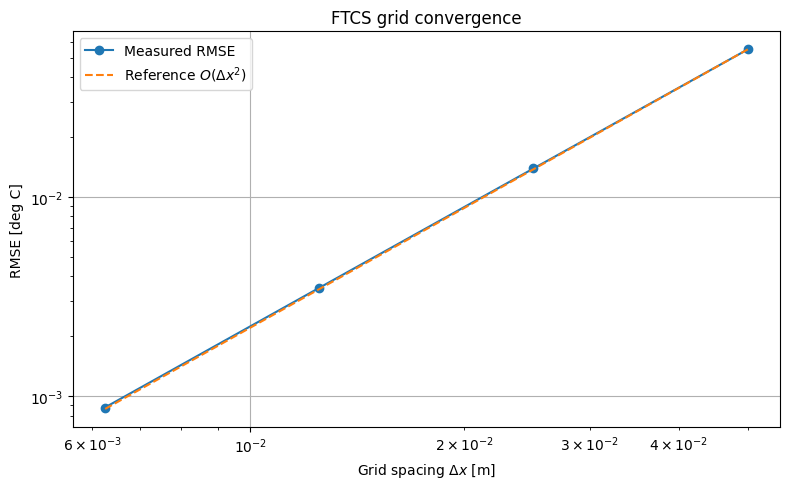

In [11]:
plt.figure(figsize=(8, 5))
plt.loglog(
    [row["dx"] for row in convergence_rows],
    [row["RMSE"] for row in convergence_rows],
    marker="o",
    label="Measured RMSE",
)

reference_dx = np.asarray([row["dx"] for row in convergence_rows])
reference_error = convergence_rows[0]["RMSE"] * (
    reference_dx / convergence_rows[0]["dx"]
) ** 2
plt.loglog(reference_dx, reference_error, "--", label=r"Reference $O(\Delta x^2)$")

plt.xlabel(r"Grid spacing $\Delta x$ [m]")
plt.ylabel("RMSE [deg C]")
plt.title("FTCS grid convergence")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 5. Physical sanity checks

Accuracy against a reference solution is necessary, but a physical model should also exhibit sensible qualitative behaviour.

For this fixed-temperature problem:

1. the boundary excess temperatures should remain zero;
2. the maximum temperature should not spontaneously increase;
3. excess heat should leave the rod through the cold boundaries.

The quantity

$$
Q^*(t)=\int_0^L u(x,t)\,dx
$$

is proportional to excess thermal energy. Actual energy would be

$$
Q(t)=\rho c_p A Q^*(t),
$$

where $A$ is the rod cross-sectional area. We normalise $Q^*(t)$ by its initial value, so material constants are unnecessary for this check.

In [12]:
def solve_ftcs_history(
    u_initial: np.ndarray,
    x_grid: np.ndarray,
    diffusivity: float,
    final_time: float,
    *,
    target_r: float = 0.4,
) -> tuple[np.ndarray, np.ndarray, FTCSDiagnostics]:
    """Return every FTCS time level for diagnostic plots."""
    dx_local = x_grid[1] - x_grid[0]
    largest_dt = target_r * dx_local**2 / diffusivity
    n_steps = int(np.ceil(final_time / largest_dt))
    dt = final_time / n_steps
    r = diffusivity * dt / dx_local**2

    u = np.asarray(u_initial, dtype=float).copy()
    u[0] = 0.0
    u[-1] = 0.0

    history = np.empty((n_steps + 1, len(u)), dtype=float)
    history[0] = u

    for step in range(1, n_steps + 1):
        u_new = u.copy()
        u_new[1:-1] = u[1:-1] + r * (
            u[2:] - 2.0 * u[1:-1] + u[:-2]
        )
        u_new[0] = 0.0
        u_new[-1] = 0.0
        u = u_new
        history[step] = u

    times = np.linspace(0.0, final_time, n_steps + 1)
    return times, history, FTCSDiagnostics(n_steps=n_steps, dt=dt, r=r)


physical_check_time = 2500.0
history_times, u_history, history_diagnostics = solve_ftcs_history(
    u_initial,
    x,
    alpha,
    physical_check_time,
    target_r=r_target,
)

normalised_excess_heat = (
    np.trapezoid(u_history, x, axis=1)
    / np.trapezoid(u_history[0], x)
)
normalised_maximum = np.max(u_history, axis=1) / np.max(u_history[0])

boundary_max_error = np.max(np.abs(u_history[:, [0, -1]]))
heat_increases = int(np.sum(np.diff(normalised_excess_heat) > 1.0e-12))
maximum_increases = int(np.sum(np.diff(normalised_maximum) > 1.0e-12))

print(f"Maximum absolute boundary value: {boundary_max_error:.3e} deg C")
print(f"Detected excess-heat increases:  {heat_increases}")
print(f"Detected maximum increases:      {maximum_increases}")

Maximum absolute boundary value: 0.000e+00 deg C
Detected excess-heat increases:  0
Detected maximum increases:      0


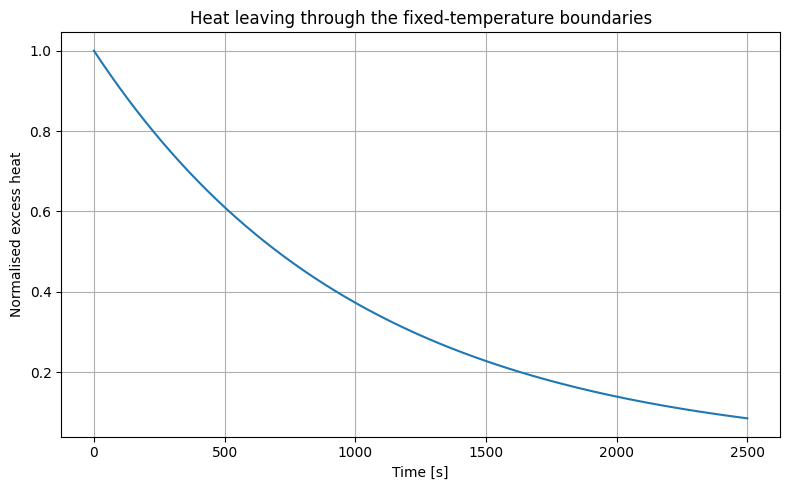

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(history_times, normalised_excess_heat)
plt.xlabel("Time [s]")
plt.ylabel("Normalised excess heat")
plt.title("Heat leaving through the fixed-temperature boundaries")
plt.grid(True)
plt.tight_layout()
plt.show()

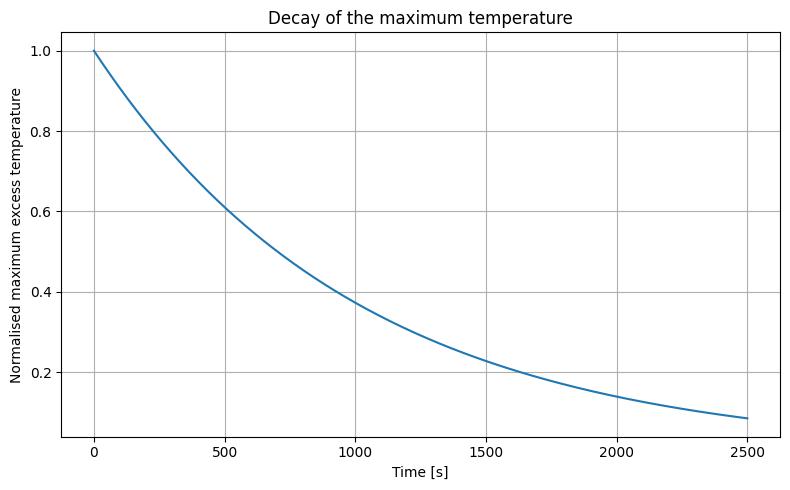

In [14]:
plt.figure(figsize=(8, 5))
plt.plot(history_times, normalised_maximum)
plt.xlabel("Time [s]")
plt.ylabel("Normalised maximum excess temperature")
plt.title("Decay of the maximum temperature")
plt.grid(True)
plt.tight_layout()
plt.show()

# 6. Machine-learning surrogate

We now ask a different question:

> Can a model learn the mapping from an initial temperature field and a requested time to the future temperature field?

The surrogate receives

$$
\left[u(x_1,0),\ldots,u(x_{N_x},0),\frac{t}{t_{\max}}\right]
$$

and predicts

$$
\left[u(x_1,t),\ldots,u(x_{N_x},t)\right].
$$

This is a **direct-time surrogate**: it predicts the field at the requested time in one evaluation rather than taking thousands of numerical time steps.

The first model is deliberately simple: a fully connected multilayer perceptron. It is a baseline, not a Fourier Neural Operator or a universal physics model.

## Important experimental design

Training and test sets are split by **initial condition**, not by individual rows. The test set therefore contains entirely unseen temperature profiles. This avoids leakage from showing the model one initial condition at one time during training and the same initial condition at another time during testing.

## 6.1 A family with exact solutions

A linear combination of sine modes also has an exact solution. Let

$$
u(x,0)=\sum_{m=1}^{M} a_m\sin\left(\frac{m\pi x}{L}\right).
$$

Then

$$
u(x,t)=\sum_{m=1}^{M}
a_m\exp\left[-\alpha\left(\frac{m\pi}{L}\right)^2t\right]
\sin\left(\frac{m\pi x}{L}\right).
$$

This gives us many non-trivial temperature fields while retaining an exact ground truth for every training and test sample.

In [15]:
N_TRAIN_MODES = 6
train_modes = np.arange(1, N_TRAIN_MODES + 1)
train_basis = np.sin(np.pi * np.outer(train_modes, x / L))
train_decay_rates = alpha * (train_modes * np.pi / L) ** 2


def exact_multimode(
    coefficients: np.ndarray,
    t_value: float,
    basis: np.ndarray = train_basis,
    decay_rates: np.ndarray = train_decay_rates,
) -> np.ndarray:
    """Exact excess-temperature field for a finite sine expansion."""
    coefficients = np.asarray(coefficients, dtype=float)
    decayed_coefficients = coefficients * np.exp(-decay_rates * t_value)
    return decayed_coefficients @ basis


def sample_coefficients(
    n_conditions: int,
    random_generator: np.random.Generator,
) -> np.ndarray:
    """
    Sample smooth multimode initial conditions.

    The first mode carries most of the amplitude. Higher modes add shape
    variation while remaining small enough to keep absolute temperatures
    in a physically reasonable range for this demonstration.
    """
    accepted: list[np.ndarray] = []

    while len(accepted) < n_conditions:
        coefficients = np.empty(N_TRAIN_MODES, dtype=float)
        coefficients[0] = random_generator.uniform(25.0, 75.0)

        mode_numbers = np.arange(2, N_TRAIN_MODES + 1)
        coefficients[1:] = random_generator.uniform(
            -15.0 / mode_numbers,
            15.0 / mode_numbers,
        )

        initial_temperature = T_base + exact_multimode(coefficients, 0.0)

        if initial_temperature.min() >= 2.0 and initial_temperature.max() <= 110.0:
            accepted.append(coefficients)

    return np.asarray(accepted)

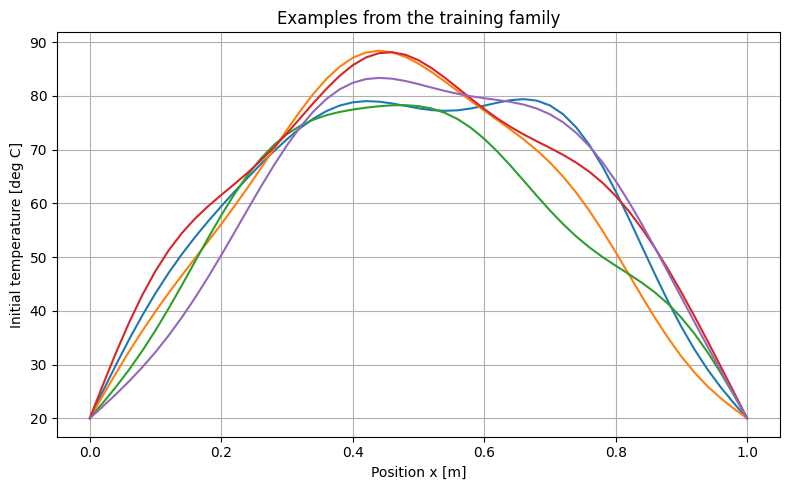

In [16]:
example_coefficients = sample_coefficients(5, rng)

plt.figure(figsize=(8, 5))
for coefficients in example_coefficients:
    plt.plot(x, T_base + exact_multimode(coefficients, 0.0))

plt.xlabel("Position x [m]")
plt.ylabel("Initial temperature [deg C]")
plt.title("Examples from the training family")
plt.grid(True)
plt.tight_layout()
plt.show()

## 6.2 Build separate training and test datasets

The training model sees six samples per initial condition:

- the exact field at $t=0$;
- five randomly selected times between 0 and 1500 s.

Evaluation uses four fixed times and entirely new initial conditions. The fixed test times make comparisons between ML and FDM reproducible.

In [17]:
T_TRAIN_MAX = 1500.0
N_TRAIN_CONDITIONS = 500
N_TEST_CONDITIONS = 100
N_RANDOM_TIMES_PER_CONDITION = 5
EVALUATION_TIMES = np.array([125.0, 425.0, 850.0, 1275.0])


def make_training_dataset(
    coefficient_matrix: np.ndarray,
    random_generator: np.random.Generator,
) -> tuple[np.ndarray, np.ndarray]:
    inputs: list[np.ndarray] = []
    targets: list[np.ndarray] = []

    for coefficients in coefficient_matrix:
        u0 = exact_multimode(coefficients, 0.0)
        sample_times = np.concatenate(
            (
                np.array([0.0]),
                random_generator.uniform(
                    0.0,
                    T_TRAIN_MAX,
                    N_RANDOM_TIMES_PER_CONDITION,
                ),
            )
        )

        for t_value in sample_times:
            model_input = np.concatenate((u0, np.array([t_value / T_TRAIN_MAX])))
            inputs.append(model_input)
            targets.append(exact_multimode(coefficients, t_value))

    return np.asarray(inputs), np.asarray(targets)


def make_evaluation_dataset(
    coefficient_matrix: np.ndarray,
    evaluation_times: np.ndarray,
) -> tuple[np.ndarray, np.ndarray]:
    inputs: list[np.ndarray] = []
    targets: list[np.ndarray] = []

    for coefficients in coefficient_matrix:
        u0 = exact_multimode(coefficients, 0.0)
        for t_value in evaluation_times:
            model_input = np.concatenate((u0, np.array([t_value / T_TRAIN_MAX])))
            inputs.append(model_input)
            targets.append(exact_multimode(coefficients, t_value))

    return np.asarray(inputs), np.asarray(targets)


train_coefficients = sample_coefficients(N_TRAIN_CONDITIONS, rng)
test_coefficients = sample_coefficients(N_TEST_CONDITIONS, rng)

X_train, Y_train = make_training_dataset(train_coefficients, rng)
X_test, Y_test = make_evaluation_dataset(test_coefficients, EVALUATION_TIMES)

print(f"Training initial conditions: {N_TRAIN_CONDITIONS}")
print(f"Test initial conditions:     {N_TEST_CONDITIONS}")
print(f"Training samples:            {len(X_train)}")
print(f"Test samples:                {len(X_test)}")
print(f"Input dimension:             {X_train.shape[1]}")
print(f"Output dimension:            {Y_train.shape[1]}")

Training initial conditions: 500
Test initial conditions:     100
Training samples:            3000
Test samples:                400
Input dimension:             52
Output dimension:            51


## 6.3 Scale and train the neural network

Inputs and outputs are standardised using statistics computed **only from the training set**.

The network has two hidden layers with 128 neurons each and hyperbolic-tangent activations. Early stopping reserves part of the training set as an internal validation set and stops when validation performance no longer improves.

The training cost is paid once. After training, each prediction is a sequence of matrix multiplications.

In [18]:
input_scaler = StandardScaler()
target_scaler = StandardScaler()

X_train_scaled = input_scaler.fit_transform(X_train)
Y_train_scaled = target_scaler.fit_transform(Y_train)

ml_model = MLPRegressor(
    hidden_layer_sizes=(128, 128),
    activation="tanh",
    solver="adam",
    alpha=1.0e-5,
    batch_size=64,
    learning_rate_init=1.0e-3,
    max_iter=800,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=40,
    random_state=SEED,
)

training_start = time.perf_counter()
ml_model.fit(X_train_scaled, Y_train_scaled)
training_seconds = time.perf_counter() - training_start

print(f"Training time: {training_seconds:.3f} s")
print(f"Iterations:    {ml_model.n_iter_}")
print(f"Final loss:    {ml_model.loss_:.8f}")

Training time: 7.085 s
Iterations:    157
Final loss:    0.00027107


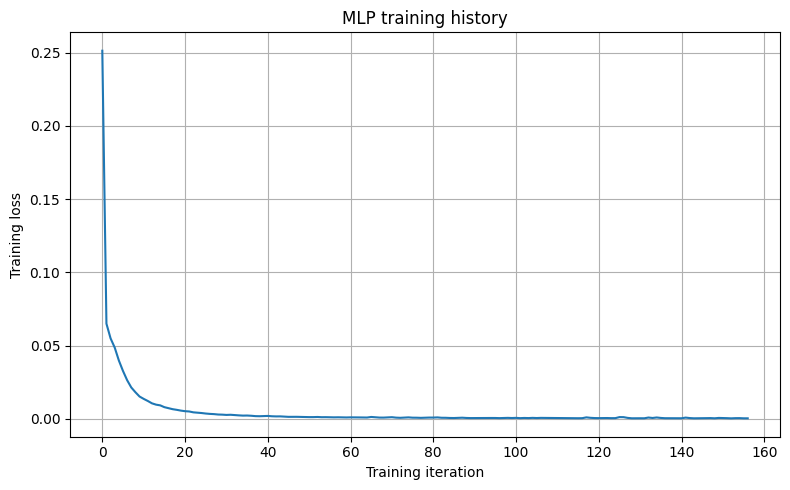

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(ml_model.loss_curve_)
plt.xlabel("Training iteration")
plt.ylabel("Training loss")
plt.title("MLP training history")
plt.grid(True)
plt.tight_layout()
plt.show()

In [20]:
def predict_ml(model_inputs: np.ndarray) -> np.ndarray:
    """Predict excess-temperature fields in physical units."""
    scaled_inputs = input_scaler.transform(model_inputs)
    scaled_prediction = ml_model.predict(scaled_inputs)
    return target_scaler.inverse_transform(scaled_prediction)


Y_ml = predict_ml(X_test)
ml_metrics = error_metrics(Y_test, Y_ml)

for name, value in ml_metrics.items():
    print(f"ML {name:>6}: {value:.6f} deg C")

ML    MAE: 0.120581 deg C
ML   RMSE: 0.165409 deg C
ML MaxAbs: 1.394569 deg C


# 7. Direct comparison: analytical, FDM, and ML

The analytical fields remain the reference.

For a fair test-set comparison, the FTCS solver is run on the same 100 unseen initial conditions and evaluated at the same four times as the neural network.

The batch implementation below vectorises over initial conditions. It still advances sequentially in time, exactly as the numerical method requires.

In [21]:
def solve_ftcs_batch_at_times(
    u_initial_batch: np.ndarray,
    x_grid: np.ndarray,
    diffusivity: float,
    evaluation_times: np.ndarray,
    *,
    target_r: float = 0.4,
) -> tuple[np.ndarray, int]:
    """
    Evolve many initial fields and save outputs at sorted evaluation times.

    Returns
    -------
    outputs:
        Array with shape (n_conditions, n_times, n_grid_points).
    total_steps:
        Total number of explicit FTCS steps.
    """
    times_array = np.asarray(evaluation_times, dtype=float)
    if np.any(np.diff(times_array) < 0.0):
        raise ValueError("evaluation_times must be sorted.")

    u = np.asarray(u_initial_batch, dtype=float).copy()
    dx_local = x_grid[1] - x_grid[0]
    maximum_dt = target_r * dx_local**2 / diffusivity

    u[:, 0] = 0.0
    u[:, -1] = 0.0

    saved_fields: list[np.ndarray] = []
    current_time = 0.0
    total_steps = 0

    for target_time in times_array:
        interval = float(target_time - current_time)

        if interval > 0.0:
            n_interval_steps = int(np.ceil(interval / maximum_dt))
            dt = interval / n_interval_steps
            r = diffusivity * dt / dx_local**2

            for _ in range(n_interval_steps):
                u_new = u.copy()
                u_new[:, 1:-1] = u[:, 1:-1] + r * (
                    u[:, 2:] - 2.0 * u[:, 1:-1] + u[:, :-2]
                )
                u_new[:, 0] = 0.0
                u_new[:, -1] = 0.0
                u = u_new

            total_steps += n_interval_steps

        saved_fields.append(u.copy())
        current_time = target_time

    return np.stack(saved_fields, axis=1), total_steps


u0_test = np.stack(
    [exact_multimode(coefficients, 0.0) for coefficients in test_coefficients]
)

fdm_start = time.perf_counter()
Y_fdm_structured, total_fdm_steps = solve_ftcs_batch_at_times(
    u0_test,
    x,
    alpha,
    EVALUATION_TIMES,
    target_r=r_target,
)
fdm_evaluation_seconds = time.perf_counter() - fdm_start

# Flatten in the same order used by make_evaluation_dataset:
# initial condition 0 at all times, then condition 1 at all times, etc.
Y_fdm = Y_fdm_structured.reshape(-1, Nx)
fdm_test_metrics = error_metrics(Y_test, Y_fdm)

print(f"Total FTCS steps to final evaluation time: {total_fdm_steps}")

Total FTCS steps to final evaluation time: 799


In [22]:
def print_metric_table(rows: list[tuple[str, dict[str, float]]]) -> None:
    print(f"{'Method':<18} {'MAE [C]':>12} {'RMSE [C]':>12} {'Max error [C]':>16}")
    for method_name, metrics in rows:
        print(
            f"{method_name:<18} "
            f"{metrics['MAE']:12.6f} "
            f"{metrics['RMSE']:12.6f} "
            f"{metrics['MaxAbs']:16.6f}"
        )


print_metric_table(
    [
        ("FTCS", fdm_test_metrics),
        ("MLP surrogate", ml_metrics),
    ]
)

Method                  MAE [C]     RMSE [C]    Max error [C]
FTCS                   0.004696     0.005712         0.020758
MLP surrogate          0.120581     0.165409         1.394569


The FDM error comes from controlled space and time discretisation. The ML error comes from finite training data, optimisation, model capacity, and generalisation to unseen initial conditions.

On this simple one-dimensional problem, a stable FDM solver is expected to be considerably more accurate. The surrogate's potential advantage is not exactness; it is the ability to produce a complete field without stepping through time after its training cost has been paid.

In [23]:
def metrics_by_evaluation_time(
    reference: np.ndarray,
    prediction: np.ndarray,
    evaluation_times: np.ndarray,
) -> list[dict[str, float]]:
    n_times = len(evaluation_times)
    rows = []
    for time_index, t_value in enumerate(evaluation_times):
        time_reference = reference[time_index::n_times]
        time_prediction = prediction[time_index::n_times]
        metrics = error_metrics(time_reference, time_prediction)
        rows.append({"time": float(t_value), **metrics})
    return rows


fdm_time_rows = metrics_by_evaluation_time(Y_test, Y_fdm, EVALUATION_TIMES)
ml_time_rows = metrics_by_evaluation_time(Y_test, Y_ml, EVALUATION_TIMES)

print(f"{'time [s]':>10} {'FTCS RMSE [C]':>17} {'ML RMSE [C]':>15}")
for fdm_row, ml_row in zip(fdm_time_rows, ml_time_rows):
    print(
        f"{fdm_row['time']:10.1f} "
        f"{fdm_row['RMSE']:17.6f} "
        f"{ml_row['RMSE']:15.6f}"
    )

  time [s]     FTCS RMSE [C]     ML RMSE [C]
     125.0          0.005394        0.215958
     425.0          0.005049        0.134629
     850.0          0.006217        0.130176
    1275.0          0.006106        0.166528


## 7.1 One unseen example

We now inspect one test initial condition that was never used during training.

In [24]:
representative_condition = 7
representative_time_index = 2
representative_time = EVALUATION_TIMES[representative_time_index]
representative_flat_index = (
    representative_condition * len(EVALUATION_TIMES)
    + representative_time_index
)

u_reference_example = Y_test[representative_flat_index]
u_fdm_example = Y_fdm[representative_flat_index]
u_ml_example = Y_ml[representative_flat_index]

print(f"Representative time: {representative_time:.1f} s")
print_metric_table(
    [
        ("FTCS", error_metrics(u_reference_example, u_fdm_example)),
        ("MLP surrogate", error_metrics(u_reference_example, u_ml_example)),
    ]
)

Representative time: 850.0 s
Method                  MAE [C]     RMSE [C]    Max error [C]
FTCS                   0.006832     0.007670         0.010967
MLP surrogate          0.168691     0.209232         0.542632


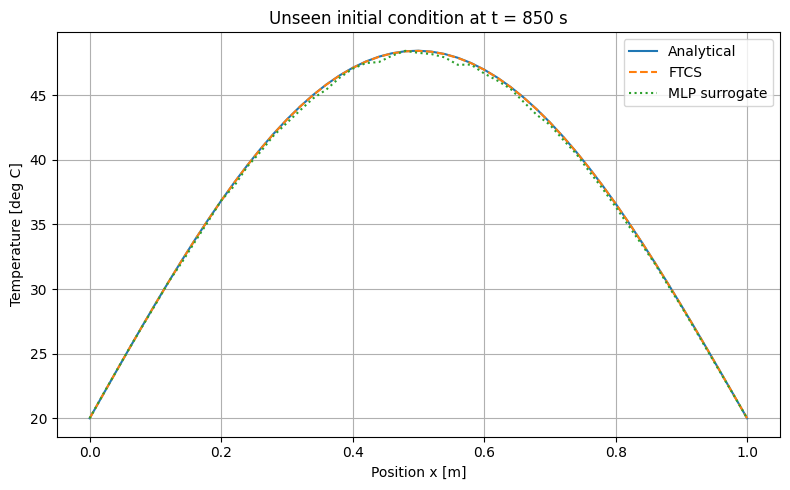

In [25]:
plt.figure(figsize=(8, 5))
plt.plot(x, T_base + u_reference_example, label="Analytical")
plt.plot(x, T_base + u_fdm_example, "--", label="FTCS")
plt.plot(x, T_base + u_ml_example, ":", label="MLP surrogate")
plt.xlabel("Position x [m]")
plt.ylabel("Temperature [deg C]")
plt.title(f"Unseen initial condition at t = {representative_time:.0f} s")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

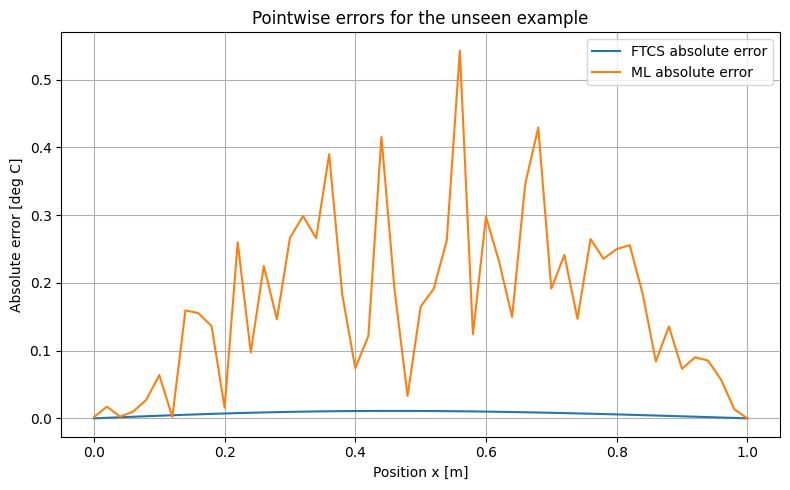

In [26]:
plt.figure(figsize=(8, 5))
plt.plot(x, np.abs(u_fdm_example - u_reference_example), label="FTCS absolute error")
plt.plot(x, np.abs(u_ml_example - u_reference_example), label="ML absolute error")
plt.xlabel("Position x [m]")
plt.ylabel("Absolute error [deg C]")
plt.title("Pointwise errors for the unseen example")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 8. Runtime and break-even comparison

Runtime measurements depend on hardware, library versions, batching, and implementation details. They should therefore be interpreted as measurements of this notebook's workload, not universal constants.

The comparison includes:

- 100 initial conditions;
- four output times for each condition;
- 400 total predicted fields.

The FDM implementation reuses its time evolution between requested output times. The ML timing includes input scaling, network inference, and inverse output scaling.

In [27]:
def median_runtime(function, repeats: int) -> float:
    measurements = []
    for _ in range(repeats):
        start = time.perf_counter()
        function()
        measurements.append(time.perf_counter() - start)
    return float(np.median(measurements))


def run_fdm_workload() -> np.ndarray:
    return solve_ftcs_batch_at_times(
        u0_test,
        x,
        alpha,
        EVALUATION_TIMES,
        target_r=r_target,
    )[0]


def run_ml_workload() -> np.ndarray:
    return predict_ml(X_test)


# Warm-up calls reduce one-off import/cache effects.
_ = run_fdm_workload()
_ = run_ml_workload()

fdm_runtime = median_runtime(run_fdm_workload, repeats=10)
ml_runtime = median_runtime(run_ml_workload, repeats=30)

n_predicted_fields = len(Y_test)
fdm_time_per_field = fdm_runtime / n_predicted_fields
ml_time_per_field = ml_runtime / n_predicted_fields
speedup = fdm_runtime / ml_runtime

print(f"Predicted fields:       {n_predicted_fields}")
print(f"FTCS workload time:     {fdm_runtime:.6f} s")
print(f"ML workload time:       {ml_runtime:.6f} s")
print(f"FTCS time per field:    {1e6 * fdm_time_per_field:.3f} microseconds")
print(f"ML time per field:      {1e6 * ml_time_per_field:.3f} microseconds")
print(f"Measured ML speed-up:   {speedup:.2f}x")

saving_per_field = fdm_time_per_field - ml_time_per_field
if saving_per_field > 0.0:
    lower_bound_break_even = training_seconds / saving_per_field
    print(f"Training-only break-even: approximately {lower_bound_break_even:,.0f} fields")
else:
    lower_bound_break_even = np.inf
    print("No runtime break-even: ML inference was not faster for this workload.")

Predicted fields:       400
FTCS workload time:     0.017041 s
ML workload time:       0.000778 s
FTCS time per field:    42.603 microseconds
ML time per field:      1.944 microseconds
Measured ML speed-up:   21.92x
Training-only break-even: approximately 174,243 fields


The break-even estimate is deliberately labelled a **lower bound**. It includes neural-network training time but excludes the cost of generating and storing the training data.

This illustrates an important point: on a coarse one-dimensional grid, the traditional solver is already extremely cheap. A surrogate becomes more compelling when the underlying solver is expensive, many repeated queries are required, or both.

# 9. Physical consistency of the ML prediction

The MLP was trained only to reduce field-prediction error. It was not explicitly told that:

- both boundaries must equal the baseline temperature;
- diffusion should obey a maximum principle;
- excess heat should decay monotonically for this boundary-value problem.

We therefore test these properties separately.

In [28]:
# Boundary errors in excess-temperature units
ml_boundary_values = Y_ml[:, [0, -1]]
boundary_mae = np.mean(np.abs(ml_boundary_values))
boundary_max = np.max(np.abs(ml_boundary_values))

# Maximum-principle violations relative to each sample's initial field and zero boundary.
u0_for_each_test_sample = X_test[:, :Nx]
lower_limit = np.minimum(0.0, np.min(u0_for_each_test_sample, axis=1))[:, None]
upper_limit = np.maximum(0.0, np.max(u0_for_each_test_sample, axis=1))[:, None]

below_violation = np.maximum(lower_limit - Y_ml, 0.0)
above_violation = np.maximum(Y_ml - upper_limit, 0.0)
maximum_principle_violation = max(
    float(np.max(below_violation)),
    float(np.max(above_violation)),
)
violating_fraction = float(
    np.mean((below_violation > 1.0e-10) | (above_violation > 1.0e-10))
)

print(f"ML boundary MAE:                  {boundary_mae:.6e} deg C")
print(f"ML maximum boundary error:        {boundary_max:.6e} deg C")
print(f"Largest maximum-principle breach: {maximum_principle_violation:.6e} deg C")
print(f"Fraction of violating values:     {100.0 * violating_fraction:.4f}%")

ML boundary MAE:                  2.085233e-03 deg C
ML maximum boundary error:        1.657381e-02 deg C
Largest maximum-principle breach: 1.657381e-02 deg C
Fraction of violating values:     1.2451%


A simple hard constraint can force the two boundary outputs to zero after prediction. This does not teach the network the PDE, but it guarantees the known Dirichlet condition.

In [29]:
Y_ml_boundary_enforced = Y_ml.copy()
Y_ml_boundary_enforced[:, 0] = 0.0
Y_ml_boundary_enforced[:, -1] = 0.0

enforced_metrics = error_metrics(Y_test, Y_ml_boundary_enforced)

print_metric_table(
    [
        ("Raw MLP", ml_metrics),
        ("Boundary-enforced", enforced_metrics),
    ]
)

Method                  MAE [C]     RMSE [C]    Max error [C]
Raw MLP                0.120581     0.165409         1.394569
Boundary-enforced      0.120500     0.165407         1.394569


## 9.1 Heat-content trajectory for one unseen condition

We evaluate the surrogate at many times for one test initial condition and compare its normalised excess heat with the analytical trajectory.

In [30]:
dense_times = np.linspace(0.0, T_TRAIN_MAX, 121)
energy_condition = 0
energy_coefficients = test_coefficients[energy_condition]
energy_u0 = exact_multimode(energy_coefficients, 0.0)

X_energy = np.stack(
    [
        np.concatenate((energy_u0, np.array([t_value / T_TRAIN_MAX])))
        for t_value in dense_times
    ]
)

u_energy_ml = predict_ml(X_energy)
u_energy_exact = np.stack(
    [exact_multimode(energy_coefficients, t_value) for t_value in dense_times]
)

exact_heat = np.trapezoid(u_energy_exact, x, axis=1)
ml_heat = np.trapezoid(u_energy_ml, x, axis=1)

exact_heat_normalised = exact_heat / exact_heat[0]
ml_heat_normalised = ml_heat / exact_heat[0]

ml_heat_increases = int(np.sum(np.diff(ml_heat_normalised) > 1.0e-8))
print(f"Detected ML heat-content increases: {ml_heat_increases}")

Detected ML heat-content increases: 0


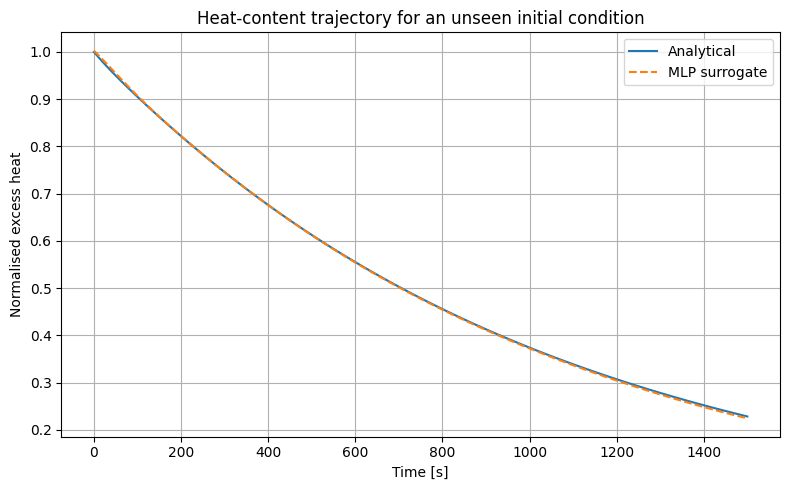

In [31]:
plt.figure(figsize=(8, 5))
plt.plot(dense_times, exact_heat_normalised, label="Analytical")
plt.plot(dense_times, ml_heat_normalised, "--", label="MLP surrogate")
plt.xlabel("Time [s]")
plt.ylabel("Normalised excess heat")
plt.title("Heat-content trajectory for an unseen initial condition")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 10. Out-of-distribution tests

Interpolation performance is not enough to establish that a learned model has captured the physics.

We now test two kinds of distribution shift:

1. **time extrapolation:** times beyond the 0–1500 s training interval;
2. **spatial-spectrum shift:** initial conditions containing higher-frequency modes absent from training.

The analytical and FDM models retain their defining equations. The MLP has only the statistical relationships present in its training data.

## 10.1 Extrapolation beyond the training-time interval

In [32]:
OOD_TIMES = np.array([1800.0, 2200.0, 3000.0])
X_ood_time, Y_ood_time = make_evaluation_dataset(test_coefficients, OOD_TIMES)
Y_ml_ood_time = predict_ml(X_ood_time)

Y_fdm_ood_structured, _ = solve_ftcs_batch_at_times(
    u0_test,
    x,
    alpha,
    OOD_TIMES,
    target_r=r_target,
)
Y_fdm_ood_time = Y_fdm_ood_structured.reshape(-1, Nx)

fdm_ood_rows = metrics_by_evaluation_time(Y_ood_time, Y_fdm_ood_time, OOD_TIMES)
ml_ood_rows = metrics_by_evaluation_time(Y_ood_time, Y_ml_ood_time, OOD_TIMES)

print(f"{'time [s]':>10} {'FTCS RMSE [C]':>17} {'ML RMSE [C]':>15}")
for fdm_row, ml_row in zip(fdm_ood_rows, ml_ood_rows):
    print(
        f"{fdm_row['time']:10.1f} "
        f"{fdm_row['RMSE']:17.6f} "
        f"{ml_row['RMSE']:15.6f}"
    )

  time [s]     FTCS RMSE [C]     ML RMSE [C]


    1800.0          0.005155        0.251001
    2200.0          0.004245        0.557645
    3000.0          0.002628        1.248554


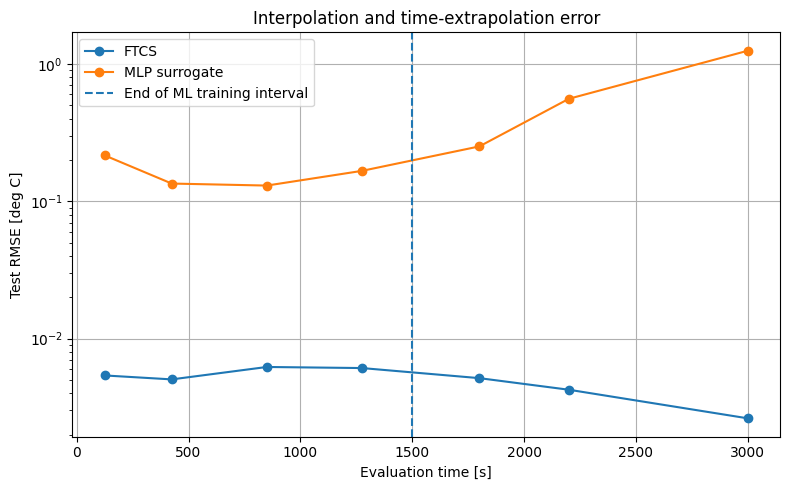

In [33]:
all_comparison_times = np.concatenate((EVALUATION_TIMES, OOD_TIMES))
fdm_all_rmse = np.array(
    [row["RMSE"] for row in fdm_time_rows]
    + [row["RMSE"] for row in fdm_ood_rows]
)
ml_all_rmse = np.array(
    [row["RMSE"] for row in ml_time_rows]
    + [row["RMSE"] for row in ml_ood_rows]
)

plt.figure(figsize=(8, 5))
plt.semilogy(all_comparison_times, fdm_all_rmse, marker="o", label="FTCS")
plt.semilogy(all_comparison_times, ml_all_rmse, marker="o", label="MLP surrogate")
plt.axvline(T_TRAIN_MAX, linestyle="--", label="End of ML training interval")
plt.xlabel("Evaluation time [s]")
plt.ylabel("Test RMSE [deg C]")
plt.title("Interpolation and time-extrapolation error")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## 10.2 Initial condition with unseen high-frequency modes

The neural network was trained only on modes $m=1,\ldots,6$. We now construct an initial condition containing modes 7 and 8.

The input dimension has not changed: the MLP still receives a 51-point temperature field. What changes is the spatial structure of that field. This test asks whether the learned mapping transfers beyond the spectral family represented in training.

In [34]:
OOD_MODE_COUNT = 8
ood_modes = np.arange(1, OOD_MODE_COUNT + 1)
ood_basis = np.sin(np.pi * np.outer(ood_modes, x / L))
ood_decay_rates = alpha * (ood_modes * np.pi / L) ** 2

ood_coefficients = np.zeros(OOD_MODE_COUNT)
ood_coefficients[0] = 55.0
ood_coefficients[6] = 8.0
ood_coefficients[7] = -5.0

ood_initial = exact_multimode(
    ood_coefficients,
    0.0,
    basis=ood_basis,
    decay_rates=ood_decay_rates,
)

ood_mode_time = 125.0
ood_mode_exact = exact_multimode(
    ood_coefficients,
    ood_mode_time,
    basis=ood_basis,
    decay_rates=ood_decay_rates,
)

ood_mode_input = np.concatenate(
    (ood_initial, np.array([ood_mode_time / T_TRAIN_MAX]))
)[None, :]
ood_mode_ml = predict_ml(ood_mode_input)[0]
ood_mode_fdm, _ = solve_ftcs(
    ood_initial,
    x,
    alpha,
    ood_mode_time,
    target_r=r_target,
)

print_metric_table(
    [
        ("FTCS", error_metrics(ood_mode_exact, ood_mode_fdm)),
        ("MLP surrogate", error_metrics(ood_mode_exact, ood_mode_ml)),
    ]
)

Method                  MAE [C]     RMSE [C]    Max error [C]
FTCS                   0.002068     0.002579         0.005056
MLP surrogate          5.661714     6.597747        13.556187


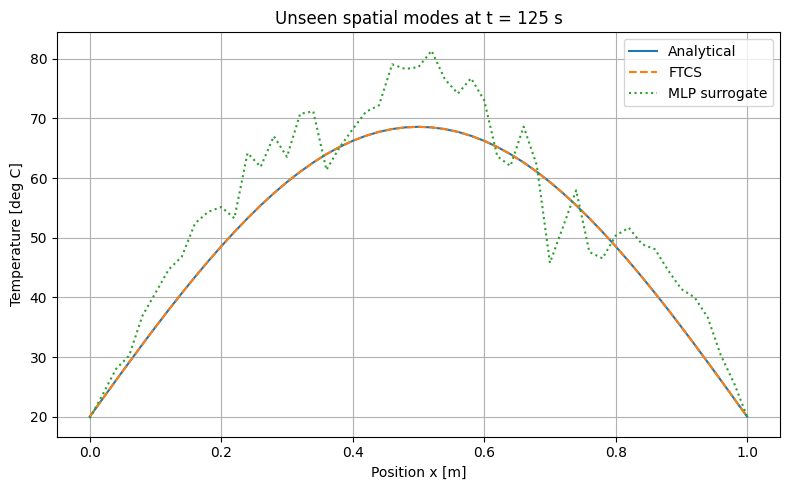

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(x, T_base + ood_mode_exact, label="Analytical")
plt.plot(x, T_base + ood_mode_fdm, "--", label="FTCS")
plt.plot(x, T_base + ood_mode_ml, ":", label="MLP surrogate")
plt.xlabel("Position x [m]")
plt.ylabel("Temperature [deg C]")
plt.title(f"Unseen spatial modes at t = {ood_mode_time:.0f} s")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 11. Conclusions

This benchmark exposes the different strengths of the three approaches.

## Analytical solution

- Exact within the assumptions and initial-condition family for which it is derived.
- Extremely useful as ground truth.
- Usually unavailable for complex geometries, nonlinear properties, heterogeneous materials, or coupled multiphysics systems.

## FTCS finite differences

- Solves the governing PDE rather than learning a statistical approximation.
- Converges toward the analytical solution at approximately second order in this setup.
- Respects the fixed boundary condition and expected diffusive behaviour by construction.
- Requires sequential time stepping and obeys the explicit stability restriction $r\le1/2$.

## MLP surrogate

- Predicts a complete future field directly after training.
- Can be faster at inference for repeated evaluations.
- Is less accurate than the simple FDM solver on this problem.
- Does not guarantee boundary conditions or maximum-principle behaviour unless these are imposed.
- Interpolates reasonably within its training distribution but degrades under time extrapolation and unseen spatial modes.

The most important conclusion is not that "ML beats physics" or that "physics beats ML." It is this:

> A learned surrogate is only as trustworthy as the domain over which it has been trained and tested. A numerical physics model carries structural knowledge that a purely data-driven model does not automatically acquire.

## Natural next experiments for EnergyPhysicsBench

1. replace the MLP with a one-dimensional CNN;
2. implement a Fourier Neural Operator;
3. vary thermal diffusivity and give the material field to the model as an input;
4. test different boundary conditions;
5. add noisy and sparse observations;
6. compare direct-time prediction with autoregressive rollout;
7. introduce conservation-aware or boundary-aware losses;
8. extend the benchmark to two-dimensional heat diffusion.

In [36]:
print("Final benchmark summary")
print("-" * 72)
print(f"FTCS test RMSE:                  {fdm_test_metrics['RMSE']:.6f} deg C")
print(f"ML test RMSE:                    {ml_metrics['RMSE']:.6f} deg C")
print(f"Observed FTCS convergence order: {observed_order:.3f}")
print(f"Measured ML inference speed-up:  {speedup:.2f}x")
print(f"ML boundary MAE:                 {boundary_mae:.3e} deg C")
print(
    "Unseen-mode RMSE (FTCS / ML):    "
    f"{error_metrics(ood_mode_exact, ood_mode_fdm)['RMSE']:.6f} / "
    f"{error_metrics(ood_mode_exact, ood_mode_ml)['RMSE']:.6f} deg C"
)

Final benchmark summary
------------------------------------------------------------------------
FTCS test RMSE:                  0.005712 deg C
ML test RMSE:                    0.165409 deg C
Observed FTCS convergence order: 1.992
Measured ML inference speed-up:  21.92x
ML boundary MAE:                 2.085e-03 deg C
Unseen-mode RMSE (FTCS / ML):    0.002579 / 6.597747 deg C
